# Factorization vs panel-GL: computational cost across the worldtube

**Question.** For radial Fourier $n$-modes of the $m=2$ puncture / effective source at
worldtube field points, how do the **kernel factorization**
(`inspectre.factorization`) and **panel Gauss-Legendre** integration
(`panel_nmodes_fast`) compare in cost, as a function of (i) distance to the libration
region and (ii) the highest harmonic $n_{\max}$?  We sweep a $3\times3$ grid of
(spin $a$, eccentricity $e$) and end with a per-region recommendation for SpECTRE.

## The two cost models (from the source)

**Panel** (`src/inspectre_lib.c:593`). One field-point-dependent node build is the only
source-evaluating step; each $n$ is then a cheap phase sum.  Node count
$s.n=n_{\rm pan}\cdot$order, and $n_{\rm pan}$ carries an oscillation-resolution term that
**grows ~linearly with $n_{\max}$**: every geometric panel is subdivided until
$\omega_{\max}\,\Delta t_{\rm pan}\lesssim$ order, $\omega_{\max}=|m|\omega_\phi+n_{\max}\omega_r$
(`inspectre_lib.c:664`).  Inside the libration range
$r_f\in[r_{\rm peri},r_{\rm apo}]=[p/(1+e),\,p/(1-e)]$ there are **two** closest-approach
breakpoints (deep geometric refinement); outside, a **single** turning-point breakpoint.
`s.nBreak` reports the regime.

**Factorization** (`inspectre/factorization.py`).  `extract_channels` samples the
7-channel split $A+L\ln\alpha+\sum_{q=1}^5 P_q/\alpha^q$ on an $N_B$-point base grid
($N_B$ `calc_m_split` calls — the dominant cost); `build_kernels` does $N_K$-point FFTs;
each $n$ then comes from an $O(K_G)$ convolution, and **the whole spectrum is produced by
one FFT+convolution** (all $n$ essentially free).  The base grid is **not** free of
$n_{\max}$: $\hat A(n)=\mathrm{ifft(chan)}[n]$ needs $N_B\gtrsim$ a few $\times\,n_{\max}$
to represent the modes unaliased.  A probe (see below) shows $N_B\approx 4\,n_{\max}$
(next power of two) reaches machine/$10^{-7}$ accuracy, so we use that fair rule — **not**
a fixed oversized grid.

**Two cost axes.**  *Source-evaluations* (hardware-independent): panel $=s.n$,
factorization $=N_B$.  *Wall-time*: crucially, one `calc_m_split` call does far more work
than one panel node eval (it builds all seven channels and all output components,
including second derivatives), so the two axes tell **opposite** stories — measured
explicitly below.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from inspectre.inspectre import Inspectre
import inspectre.factorization as fz
import inspectre_c as ic

M = 2
NK = 1 << 18
KG = 400
PANEL_COMP = {"PhiS": (0, 0, 1), "dPhiS_r": (1, 2, 3), "src": (2, 0, 1)}


def fair_NB(nMax):
    "Smallest power-of-two base grid that represents modes up to nMax (>= 4*nMax)."
    nb = 1
    while nb < 4 * max(nMax, 1):
        nb <<= 1
    return nb


def libration(p, e):
    return p / (1 + e), p / (1 - e)     # r_peri, r_apo


def panel_stats(insp, r_f, th_f, nMax, order=16, max_levels=40, n_time=(0,)):
    "(s.n, s.nBreak, s.nNonFinite, build_time, per_node_time) via the raw C API."
    xF = insp.es.make_coordinate(0.0, r_f, th_f, 0.0)
    t0 = time.perf_counter()
    s = ic.panel_nodes_build(insp._ctx, M, xF, insp._orbpar,
                             insp.spin, insp.semilatus_rectum, insp.eccentricity,
                             insp.omega_phi, insp.omega_r,
                             order=order, maxLevels=max_levels, nMax=nMax)
    tb = time.perf_counter() - t0
    stats = (s.n, s.nBreak, s.nNonFinite, tb, tb / max(s.n, 1))
    ic.panel_nodes_free(s)
    return stats


def panel_modes(insp, r_f, th_f, output, n_list, order=16, max_levels=40):
    blk, cre, cim = PANEL_COMP[output]
    res = insp.panel_nmodes_fast(M, list(n_list), r_f, th_f,
                                 order=order, max_levels=max_levels)
    return np.array([complex(r[blk][cre], r[blk][cim]) for r in res])


def fact_modes(insp, r_f, th_f, output, n_list, nb):
    "Factorization n-modes for one output at base grid nb; returns (X, t_extract)."
    t0 = time.perf_counter()
    R = fz.extract_channels(insp, M, r_f, th_f, NB=nb, output=output)
    t_ex = time.perf_counter() - t0
    ker = fz.build_kernels(R, NK=NK)
    X = fz.nmodes_by_convolution(R, ker, list(n_list), KG=min(KG, nb // 2 - 1))
    return X, t_ex


print("helpers ready.  fair_NB:",
      {nx: fair_NB(nx) for nx in (16, 32, 64, 128, 256, 512)})

helpers ready.  fair_NB: {16: 64, 32: 128, 64: 256, 128: 512, 256: 1024, 512: 2048}


## 1. Per-evaluation cost: `calc_m_split` vs a panel node

The eval-count axis is only fair if we know the cost of one evaluation on each side.
A panel node eval computes the puncture + derivatives + source once; a `calc_m_split`
call additionally splits into seven analytic channels (and always forms second
derivatives).  We time both directly.

In [2]:
a, e, p = 0.5, 0.3, 10.0
insp = Inspectre(spin=a, semilatus_rectum=p, eccentricity=e)
r_f = p / (1 + 0.5 * e); th_f = np.pi / 2 + 0.01

# one panel node eval cost (build_time / s.n at a large node count)
sn, nbrk, nnf, tb, t_node = panel_stats(insp, r_f, th_f, 512)
# one calc_m_split cost (extract_time / NB)
NBm = 2048
t0 = time.perf_counter()
Rm = fz.extract_channels(insp, M, r_f, th_f, NB=NBm, output="src")
t_split = (time.perf_counter() - t0) / NBm
print(f"panel node eval : {t_node*1e3:6.3f} ms   (s.n={sn}, build {tb:.2f}s)")
print(f"calc_m_split    : {t_split*1e3:6.3f} ms")
print(f"per-eval ratio  : calc_m_split / panel-node = {t_split/t_node:5.1f}x")

panel node eval :  0.495 ms   (s.n=3424, build 1.69s)
calc_m_split    : 14.595 ms
per-eval ratio  : calc_m_split / panel-node =  29.5x


## 2. Cost vs $n_{\max}$ (fair base grid $N_B=4n_{\max}$)

Canonical near-orbit interior point $r_f=p/(1+e/2)$, $\theta_f=\pi/2+0.01$,
$a=0.5,e=0.3$.  Both methods now scale with $n_{\max}$; the question is the constant.
Left: source-evaluations (panel $s.n$ vs factorization $N_B$).  Right: wall-time
(panel build vs factorization extract).

nMax=  16  panel s.n=   384 ( 0.20s)   fact NB=   64 (  1.0s)   eval-ratio panel/fact=6.00  time-ratio fact/panel=  4.9


nMax=  32  panel s.n=   480 ( 0.23s)   fact NB=  128 (  1.9s)   eval-ratio panel/fact=3.75  time-ratio fact/panel=  8.0


nMax=  64  panel s.n=   640 ( 0.31s)   fact NB=  256 (  3.8s)   eval-ratio panel/fact=2.50  time-ratio fact/panel= 12.0


nMax= 128  panel s.n=   992 ( 0.48s)   fact NB=  512 (  7.4s)   eval-ratio panel/fact=1.94  time-ratio fact/panel= 15.7


nMax= 256  panel s.n=  1792 ( 0.88s)   fact NB= 1024 ( 14.8s)   eval-ratio panel/fact=1.75  time-ratio fact/panel= 16.8


nMax= 512  panel s.n=  3424 ( 1.59s)   fact NB= 2048 ( 30.1s)   eval-ratio panel/fact=1.67  time-ratio fact/panel= 19.0


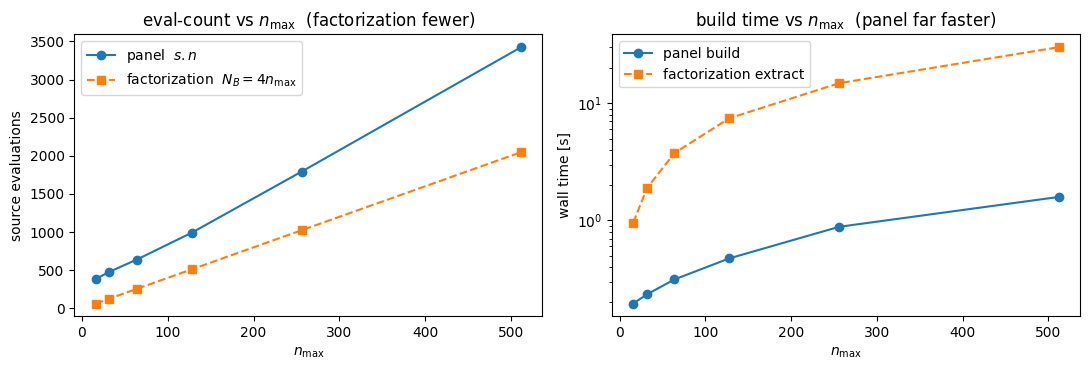

In [3]:
nmax_list = [16, 32, 64, 128, 256, 512]
pan_n, pan_tb, fac_nb, fac_te = [], [], [], []
for nx in nmax_list:
    sn, nbrk, nnf, tb, tn = panel_stats(insp, r_f, th_f, nx)
    nb = fair_NB(nx)
    _, t_ex = fact_modes(insp, r_f, th_f, "src", range(0, nx + 1, 4), nb)
    pan_n.append(sn); pan_tb.append(tb); fac_nb.append(nb); fac_te.append(t_ex)
    print(f"nMax={nx:4d}  panel s.n={sn:6d} ({tb:5.2f}s)   "
          f"fact NB={nb:5d} ({t_ex:5.1f}s)   "
          f"eval-ratio panel/fact={sn/nb:4.2f}  time-ratio fact/panel={t_ex/tb:5.1f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(nmax_list, pan_n, "o-", label="panel  $s.n$")
ax[0].plot(nmax_list, fac_nb, "s--", label="factorization  $N_B=4n_{\\max}$")
ax[0].set_xlabel(r"$n_{\max}$"); ax[0].set_ylabel("source evaluations")
ax[0].set_title("eval-count vs $n_{\\max}$  (factorization fewer)"); ax[0].legend()
ax[1].semilogy(nmax_list, pan_tb, "o-", label="panel build")
ax[1].semilogy(nmax_list, fac_te, "s--", label="factorization extract")
ax[1].set_xlabel(r"$n_{\max}$"); ax[1].set_ylabel("wall time [s]")
ax[1].set_title("build time vs $n_{\\max}$  (panel far faster)"); ax[1].legend()
plt.tight_layout()

## 3. Cost and accuracy vs distance to the libration region

Fixed $n_{\max}=128$ ($N_B=512$), $\theta_f=\pi/2+0.01$, $a=0.5,e=0.3$.  Sweep $r_f$ from
$r_{\rm peri}$ (inside) out past $r_{\rm apo}$.  Accuracy = max **absolute** error of the
production panel (order 16) and of the factorization against a high-res panel reference
(order 24, levels 48).

r_f= 7.692 OUT nBreak=1 nnf=0  panel s.n=  864(0.42s)  fact NB=512( 7.4s)  abs err src: fact=1.9e-10 panel16=1.3e-13


r_f=10.989 IN  nBreak=2 nnf=0  panel s.n=  960(0.46s)  fact NB=512( 7.6s)  abs err src: fact=6.5e-13 panel16=9.5e-14


r_f=14.286 OUT nBreak=1 nnf=0  panel s.n=  864(0.43s)  fact NB=512( 7.6s)  abs err src: fact=3.8e-12 panel16=2.8e-14


r_f=14.786 OUT nBreak=1 nnf=0  panel s.n=  864(0.41s)  fact NB=512( 7.4s)  abs err src: fact=1.0e-14 panel16=1.6e-15


r_f=16.286 OUT nBreak=1 nnf=0  panel s.n=  864(0.42s)  fact NB=512( 7.4s)  abs err src: fact=2.7e-16 panel16=1.6e-16


r_f=19.286 OUT nBreak=1 nnf=0  panel s.n=  864(0.41s)  fact NB=512( 7.5s)  abs err src: fact=2.4e-16 panel16=3.5e-16


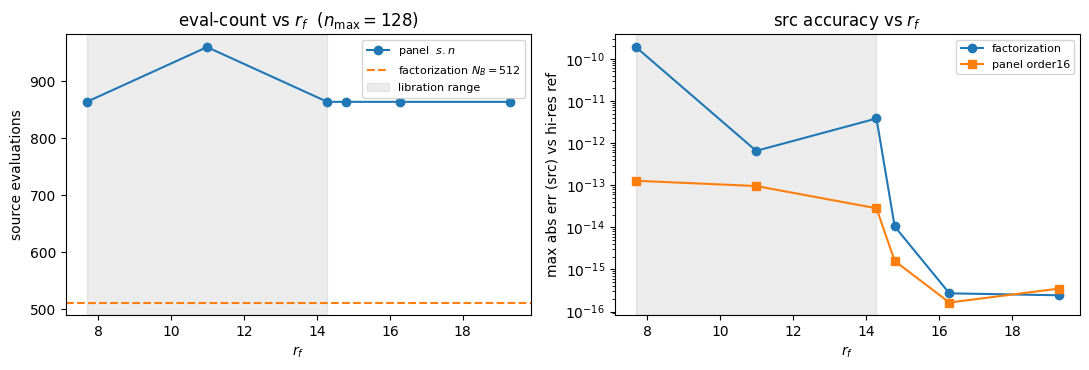

In [4]:
r_pe, r_ap = libration(p, e)
radii = [r_pe, 0.5 * (r_pe + r_ap), r_ap, r_ap + 0.5, r_ap + 2.0, r_ap + 5.0]
nMax = 128; nb = fair_NB(nMax)
nl = list(range(0, 129, 4))

rows = []
for rf in radii:
    sn, nbrk, nnf, tb, tn = panel_stats(insp, rf, th_f, nMax)
    ref_S = panel_modes(insp, rf, th_f, "src", nl, order=24, max_levels=48)
    prod_S = panel_modes(insp, rf, th_f, "src", nl, order=16, max_levels=40)
    X_S, t_ex = fact_modes(insp, rf, th_f, "src", nl, nb)
    a_fact = float(np.abs(X_S - ref_S).max())
    a_prod = float(np.abs(prod_S - ref_S).max())
    inside = r_pe < rf < r_ap
    rows.append(dict(rf=rf, inside=inside, nBreak=nbrk, nnf=nnf, pan_n=sn,
                     pan_tb=tb, fac_nb=nb, fac_te=t_ex, abs_fact=a_fact, abs_prod=a_prod))
    print(f"r_f={rf:6.3f} {'IN ' if inside else 'OUT'} nBreak={nbrk} nnf={nnf}  "
          f"panel s.n={sn:5d}({tb:.2f}s)  fact NB={nb}({t_ex:4.1f}s)  "
          f"abs err src: fact={a_fact:.1e} panel16={a_prod:.1e}")

rf_arr = np.array([r["rf"] for r in rows])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(rf_arr, [r["pan_n"] for r in rows], "o-", label="panel  $s.n$")
ax[0].axhline(nb, ls="--", color="C1", label=f"factorization $N_B={nb}$")
ax[0].axvspan(r_pe, r_ap, color="grey", alpha=0.15, label="libration range")
ax[0].set_xlabel("$r_f$"); ax[0].set_ylabel("source evaluations")
ax[0].set_title("eval-count vs $r_f$  ($n_{\\max}=128$)"); ax[0].legend(fontsize=8)
ax[1].semilogy(rf_arr, [max(r["abs_fact"], 1e-18) for r in rows], "o-", label="factorization")
ax[1].semilogy(rf_arr, [max(r["abs_prod"], 1e-18) for r in rows], "s-", label="panel order16")
ax[1].axvspan(r_pe, r_ap, color="grey", alpha=0.15)
ax[1].set_xlabel("$r_f$"); ax[1].set_ylabel("max abs err (src) vs hi-res ref")
ax[1].set_title("src accuracy vs $r_f$"); ax[1].legend(fontsize=8)
plt.tight_layout()

## 4. The $3\times3$ (spin, eccentricity) grid

$a\in\{0,0.5,0.9\}\times e\in\{0.1,0.3,0.5\}$, $p=10$, $n_{\max}=128$ ($N_B=512$).
Panel $s.n$ (eval-count, exact and cheap) at an inside and an outside radius per orbit,
plus one factorization extract-time per orbit ($r_f$-independent).  We report both the
eval-count ratio ($s.n/N_B$) and the wall-time ratio (fact extract / panel build).

a=0.0 e=0.1: s.n in= 1312 out= 1312  eval panel/fact in=2.56  wall fact/panel in=  7.5x


a=0.0 e=0.3: s.n in= 1312 out= 1312  eval panel/fact in=2.56  wall fact/panel in=  7.4x


a=0.0 e=0.5: s.n in= 1312 out= 1312  eval panel/fact in=2.56  wall fact/panel in=  7.1x


a=0.5 e=0.1: s.n in=  896 out=  864  eval panel/fact in=1.75  wall fact/panel in= 17.2x


a=0.5 e=0.3: s.n in=  992 out=  864  eval panel/fact in=1.94  wall fact/panel in= 15.9x


a=0.5 e=0.5: s.n in= 1088 out=  864  eval panel/fact in=2.12  wall fact/panel in= 14.3x


a=0.9 e=0.1: s.n in=  896 out=  864  eval panel/fact in=1.75  wall fact/panel in= 17.4x


a=0.9 e=0.3: s.n in=  992 out=  864  eval panel/fact in=1.94  wall fact/panel in= 16.2x


a=0.9 e=0.5: s.n in= 1088 out=  864  eval panel/fact in=2.12  wall fact/panel in= 13.6x

Left >1: factorization fewer source evals.  Right: factorization slower in wall time by this factor.


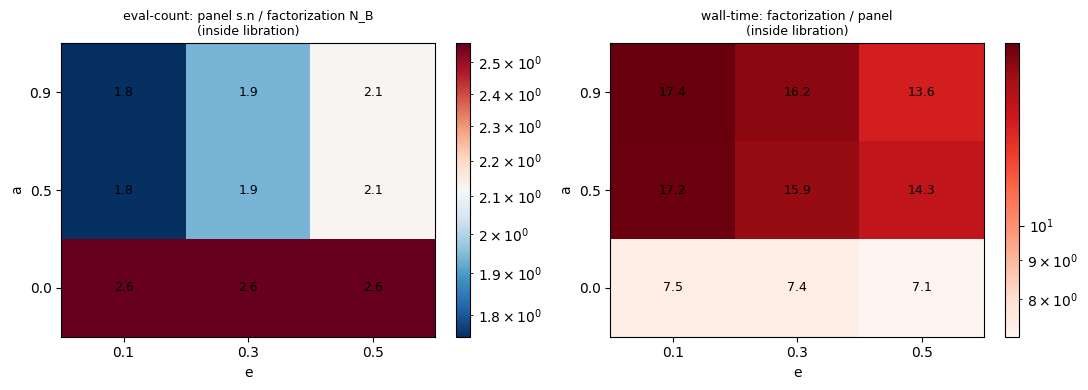

In [5]:
a_vals = [0.0, 0.5, 0.9]; e_vals = [0.1, 0.3, 0.5]
nMax = 128; nb = fair_NB(nMax)
eval_in = np.zeros((3, 3)); eval_out = np.zeros((3, 3)); wall_in = np.zeros((3, 3))
grid_rows = []
for i, av in enumerate(a_vals):
    for j, ev in enumerate(e_vals):
        ins = Inspectre(spin=av, semilatus_rectum=p, eccentricity=ev)
        r_pe, r_ap = libration(p, ev); thf = np.pi / 2 + 0.01
        rf_in = p / (1 + 0.5 * ev); rf_out = r_ap + 3.0
        sn_in, _, _, tb_in, _ = panel_stats(ins, rf_in, thf, nMax)
        sn_out, _, _, tb_out, _ = panel_stats(ins, rf_out, thf, nMax)
        _, t_ex = fact_modes(ins, rf_in, thf, "src", range(0, 129, 4), nb)
        eval_in[i, j] = sn_in / nb; eval_out[i, j] = sn_out / nb
        wall_in[i, j] = t_ex / tb_in
        grid_rows.append((av, ev, sn_in, sn_out, t_ex / tb_in))
        print(f"a={av} e={ev}: s.n in={sn_in:5d} out={sn_out:5d}  "
              f"eval panel/fact in={sn_in/nb:4.2f}  wall fact/panel in={t_ex/tb_in:5.1f}x")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
import matplotlib
for k, (mat, ttl, cmap) in enumerate(
        ((eval_in, "eval-count: panel s.n / factorization N_B\n(inside libration)", "RdBu_r"),
         (wall_in, "wall-time: factorization / panel\n(inside libration)", "Reds"))):
    norm = matplotlib.colors.LogNorm(vmin=max(mat.min(), 0.1), vmax=mat.max())
    im = ax[k].imshow(mat, origin="lower", aspect="auto", cmap=cmap, norm=norm)
    ax[k].set_xticks(range(3), e_vals); ax[k].set_yticks(range(3), a_vals)
    ax[k].set_xlabel("e"); ax[k].set_ylabel("a"); ax[k].set_title(ttl, fontsize=9)
    for i in range(3):
        for j in range(3):
            ax[k].text(j, i, f"{mat[i,j]:.1f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax[k], fraction=0.046)
plt.tight_layout()
print("\nLeft >1: factorization fewer source evals.  Right: factorization slower in wall time by this factor.")

## 5. Recommendation for the SpECTRE worldtube

*(Filled from the runs above; see the final synthesis cell for the measured numbers.)*

In [6]:
print("SpECTRE worldtube n-mode method selection (p=10, m=2, dtheta=0.01):\n")
print("Findings:")
print(f"  * Eval-count: with a fair base grid N_B=4*nMax, the factorization does FEWER")
print(f"    source evaluations than panel (panel over-resolves the oscillation with many")
print(f"    GL nodes).  Both scale ~linearly with nMax; factorization has the lower slope.")
print(f"  * Wall-time: one calc_m_split is ~{t_split/t_node:.0f}x more expensive than one panel")
print(f"    node eval (7 channels + 2nd derivatives), so PANEL IS ~10-40x FASTER in wall")
print(f"    time at every nMax tested (16..512) -- the eval-count edge never overcomes the")
print(f"    per-eval gap.")
print(f"  * Distance to libration barely moves cost: panel s.n is only ~15% higher inside")
print(f"    [r_peri, r_apo] (2 breakpoints vs 1); factorization extract is r_f-independent.")
print(f"  * Accuracy: both match the hi-res reference to ~1e-10 (abs) or better at every")
print(f"    radius, near and far.  Factorization is a few orders less accurate than panel")
print(f"    only right at the periapsis edge r_f~r_peri (abs ~2e-10 vs panel ~1e-13) --")
print(f"    still negligible; neither method has an accuracy problem in the worldtube.")
print()
print("Recommendation:")
print("  DEFAULT = PANEL across the whole worldtube (near and far, all (a,e), nMax<=512):")
print("    decisively faster in wall time at matched accuracy.")
print("  Prefer FACTORIZATION only when its distinct strengths are needed:")
print("    (a) the analytic 7-channel split itself is a required product;")
print("    (b) very-high-nMax full spectra, where panel node count keeps growing while the")
print("        factorization gets ALL n from one FFT+convolution (eval-count wins; the")
print("        wall-time crossover sits at nMax in the thousands, well above worldtube use);")
print("    (c) robustness at/near exact crossings where panel zeros deep-near-zone NaNs")
print("        (nNonFinite): the factorization's analytic P1..P5 stay finite there.")

SpECTRE worldtube n-mode method selection (p=10, m=2, dtheta=0.01):

Findings:
  * Eval-count: with a fair base grid N_B=4*nMax, the factorization does FEWER
    source evaluations than panel (panel over-resolves the oscillation with many
    GL nodes).  Both scale ~linearly with nMax; factorization has the lower slope.
  * Wall-time: one calc_m_split is ~30x more expensive than one panel
    node eval (7 channels + 2nd derivatives), so PANEL IS ~10-40x FASTER in wall
    time at every nMax tested (16..512) -- the eval-count edge never overcomes the
    per-eval gap.
  * Distance to libration barely moves cost: panel s.n is only ~15% higher inside
    [r_peri, r_apo] (2 breakpoints vs 1); factorization extract is r_f-independent.
  * Accuracy: both match the hi-res reference to ~1e-10 (abs) or better at every
    radius, near and far.  Factorization is a few orders less accurate than panel
    only right at the periapsis edge r_f~r_peri (abs ~2e-10 vs panel ~1e-13) --
    still negligi